In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.calibration import calibration_curve
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All imports successful')

All imports successful


In [2]:
df = pd.read_csv('IPL.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nFirst 2 rows:')
df.head(2)

Shape: (283678, 65)

Columns: ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']

Data types:
Unnamed: 0           int64
match_id             int64
d

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [3]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('Columns with missing values:')
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

Columns with missing values:
                   Missing Count  Missing %
power_surge_start         283678     100.00
review_batter             282771      99.68
team_reviewed             282771      99.68
review_decision           282771      99.68
umpire                    282771      99.68
superover_winner          279782      98.63
method                    279788      98.63
result_type               278954      98.33
fielders                  273433      96.39
new_batter                270085      95.21
next_batter               270085      95.21
wicket_kind               269572      95.03
player_out                269572      95.03
extra_type                268185      94.54
runs_target               147168      51.88
win_outcome                 4724       1.67


In [4]:
# Check season and innings distribution
print('Season distribution (raw):')
print(df['season'].value_counts())
print('\nInnings distribution:')
print(df['innings'].value_counts())

Season distribution (raw):
season
2013       18177
2022       17912
2023       17863
2012       17767
2025       17285
2024       17103
2020/21    14559
2009/10    14498
2014       14300
2018       14286
2016       14096
2017       13862
2015       13652
2007/08    13489
2021       11434
2011        9454
2009        8192
2011        7559
2019        7286
2019        7026
2026        5473
2009        5414
2021        2991
Name: count, dtype: int64

Innings distribution:
innings
1    146997
2    136510
3        83
4        76
5         8
6         4
Name: count, dtype: int64


In [5]:
# Fix 1: Standardize season column
df['season'] = df['season'].astype(str).str.strip().str.replace('/', '-')

# Fix 2: Remove Super Overs (innings 3+)
df = df[df['innings'].isin([1, 2])].copy()

# Fix 3: Standardize team names (franchises that changed names)
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Pune Warriors': 'Pune Warriors India'
}
df['batting_team'] = df['batting_team'].replace(team_name_map)
df['bowling_team'] = df['bowling_team'].replace(team_name_map)

print('Shape after cleaning:', df.shape)
print('\nSeasons after fix:')
print(df['season'].value_counts().sort_index())
print('\nUnique teams:')
print(sorted(df['batting_team'].unique()))

Shape after cleaning: (283507, 65)

Seasons after fix:
season
2007-08    13489
2009       13595
2009-10    14489
2011       17013
2012       17767
2013       18152
2014       14288
2015       13641
2016       14096
2017       13849
2018       14286
2019       14293
2020-21    14510
2021       14413
2022       17912
2023       17863
2024       17103
2025       17275
2026        5473
Name: count, dtype: int64

Unique teams:
['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors India', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


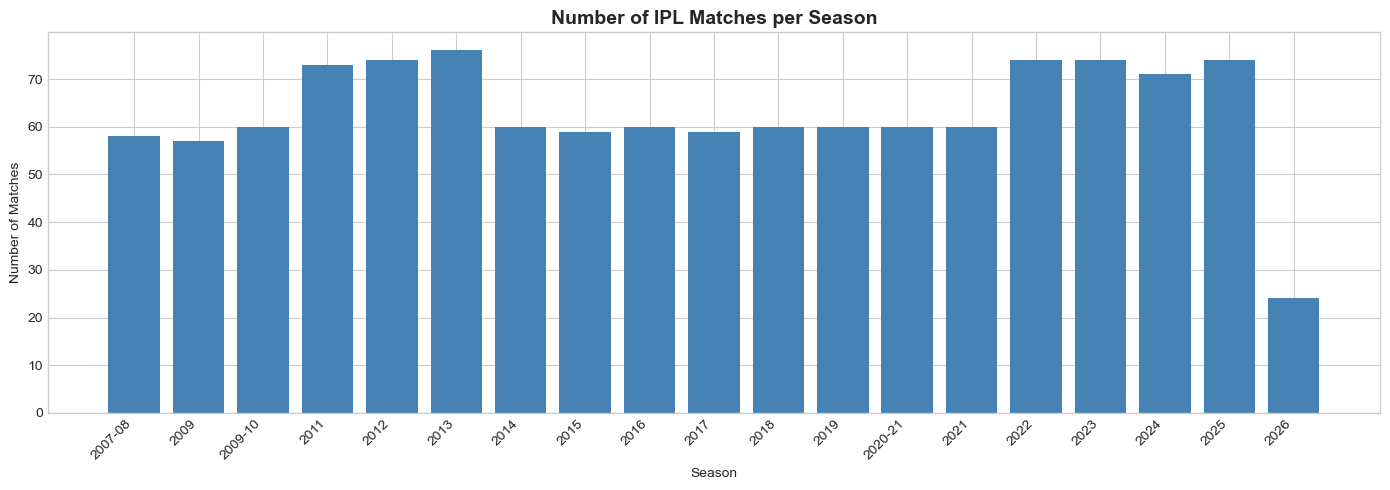

Total matches: 1193


In [6]:
# EDA on full dataset - matches per season
matches_per_season = df.groupby('season')['match_id'].nunique().reset_index()
matches_per_season.columns = ['season', 'matches']

plt.figure(figsize=(14, 5))
plt.bar(matches_per_season['season'], matches_per_season['matches'], color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Number of IPL Matches per Season', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.savefig('eda_matches_per_season.png', dpi=150)
plt.show()
print('Total matches:', df['match_id'].nunique())

Toss winner win rate: 37.0%


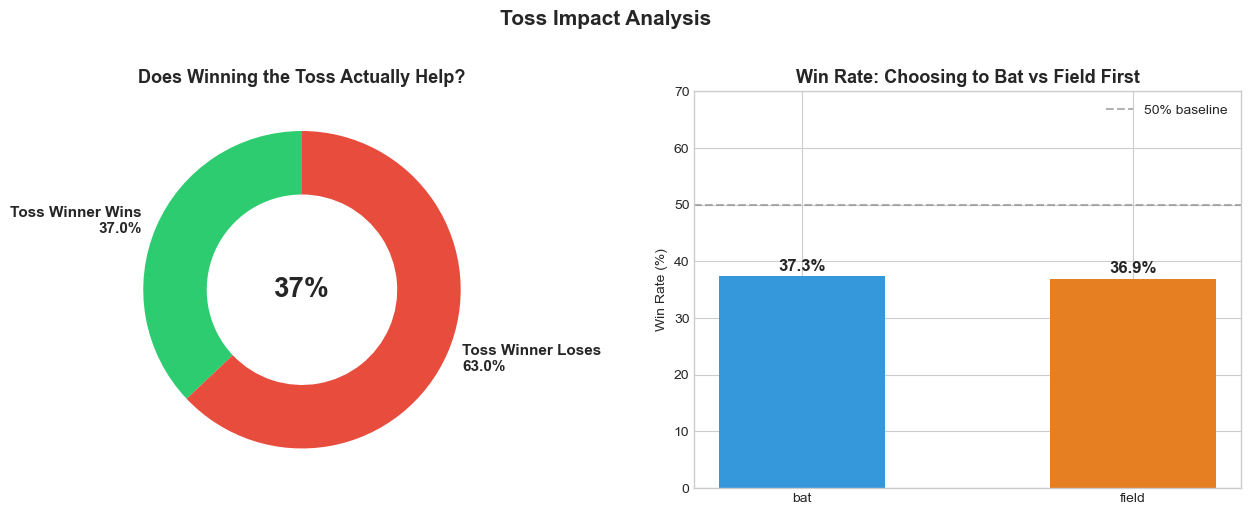

In [37]:
toss_df = df.drop_duplicates('match_id')[['match_id', 'season', 'toss_winner', 'batting_team', 
                                          'bowling_team', 'win_outcome', 'toss_decision']].copy()

toss_df['match_winner'] = np.where(
    toss_df['win_outcome'].str.contains('wicket', case=False, na=False),
    toss_df['batting_team'],
    toss_df['bowling_team']
)
toss_df['toss_winner_won'] = (toss_df['toss_winner'] == toss_df['match_winner']).astype(int)

toss_win_rate = toss_df['toss_winner_won'].mean()
print(f'Toss winner win rate: {toss_win_rate:.1%}')
# Visualize toss winner advantage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Toss winner win rate (donut chart)
sizes = [toss_win_rate * 100, (1 - toss_win_rate) * 100]
labels = [f'Toss Winner Wins\n{toss_win_rate:.1%}', f'Toss Winner Loses\n{1-toss_win_rate:.1%}']
colors_donut = ['#2ecc71', '#e74c3c']

axes[0].pie(sizes, labels=labels, colors=colors_donut, autopct='', 
            startangle=90, wedgeprops=dict(width=0.4), textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0].add_artist(plt.Circle((0,0), 0.3, color='white'))
axes[0].set_title('Does Winning the Toss Actually Help?', fontsize=13, fontweight='bold')
axes[0].text(0, 0, f'{toss_win_rate:.0%}', ha='center', va='center', fontsize=20, fontweight='bold')

# Plot 2: Win rate by toss decision (bat vs field)
bars = axes[1].bar(toss_decision_wr.index, toss_decision_wr.values * 100, 
                     color=['#3498db', '#e67e22'], width=0.5)
for bar, val in zip(bars, toss_decision_wr.values * 100):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[1].axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% baseline')
axes[1].set_title('Win Rate: Choosing to Bat vs Field First', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].legend()

plt.suptitle('Toss Impact Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_toss_impact.png', dpi=150, bbox_inches='tight')
plt.show()



<Figure size 1400x500 with 0 Axes>

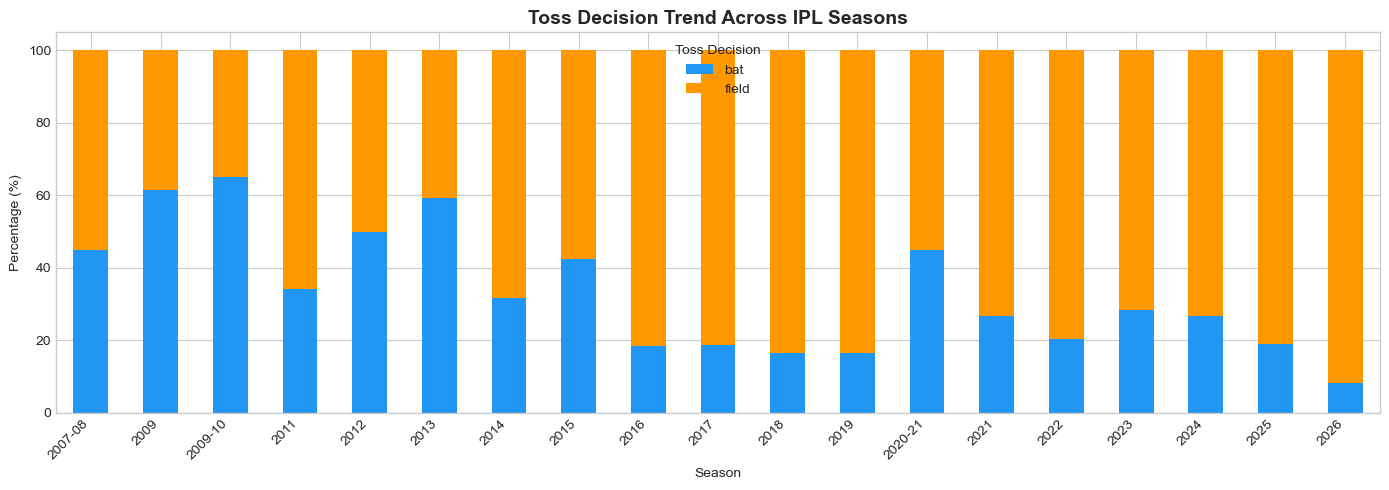

In [38]:
# Toss decision trend over seasons
toss_trend = toss_df.groupby(['season', 'toss_decision']).size().unstack(fill_value=0)
toss_trend_pct = toss_trend.div(toss_trend.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 5))
toss_trend_pct.plot(kind='bar', stacked=True, figsize=(14, 5), 
                    color=['#2196F3', '#FF9800'])
plt.title('Toss Decision Trend Across IPL Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Toss Decision')
plt.tight_layout()
plt.savefig('eda_toss_trend.png', dpi=150)
plt.show()

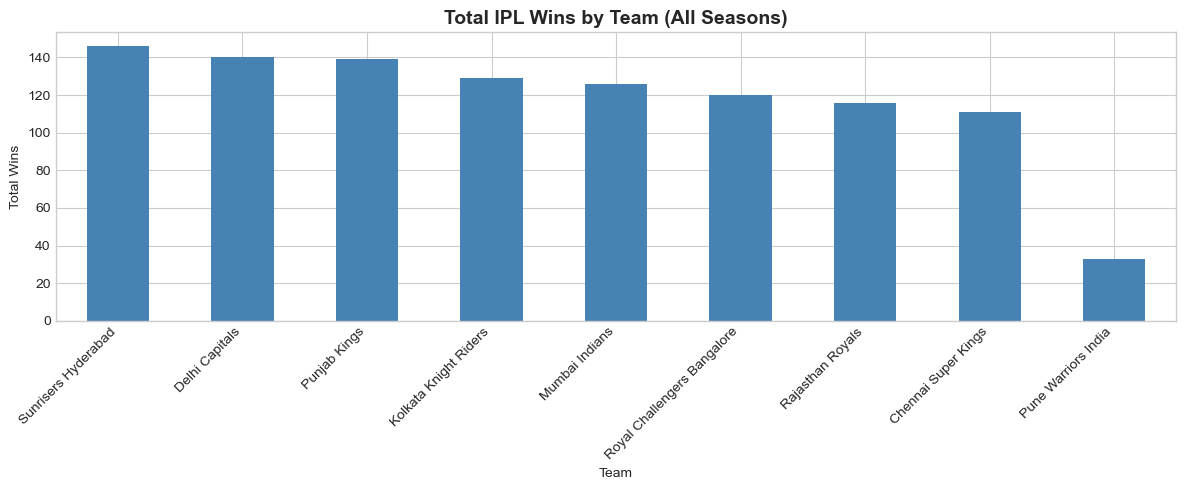

Sunrisers Hyderabad            146
Delhi Capitals                 140
Punjab Kings                   139
Kolkata Knight Riders          129
Mumbai Indians                 126
Royal Challengers Bangalore    120
Rajasthan Royals               116
Chennai Super Kings            111
Pune Warriors India             33
Name: count, dtype: int64


In [13]:
# Most successful teams overall
wins_batting = toss_df[toss_df['win_outcome'].str.contains('wicket', case=False, na=False)]['batting_team'].value_counts()
wins_bowling = toss_df[toss_df['win_outcome'].str.contains('run', case=False, na=False)]['bowling_team'].value_counts()
total_wins = (wins_batting.add(wins_bowling, fill_value=0)).sort_values(ascending=False)

# Filter to main franchises (more than 30 wins)
total_wins = total_wins[total_wins > 30]

plt.figure(figsize=(12, 5))
total_wins.plot(kind='bar', color='steelblue')
plt.title('Total IPL Wins by Team (All Seasons)', fontsize=14, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Total Wins')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_team_wins.png', dpi=150)
plt.show()
print(total_wins)

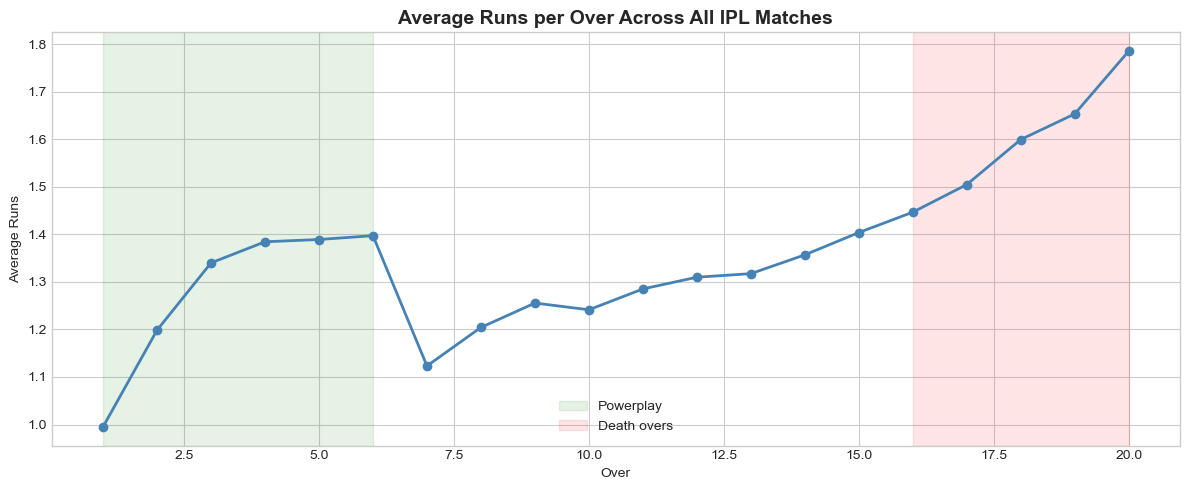

In [14]:
# Average runs scored per over across all matches
over_runs = df[df['innings'].isin([1,2])].groupby('over')['runs_total'].mean()

plt.figure(figsize=(12, 5))
plt.plot(over_runs.index + 1, over_runs.values, marker='o', linewidth=2, color='steelblue')
plt.axvspan(1, 6, alpha=0.1, color='green', label='Powerplay')
plt.axvspan(16, 20, alpha=0.1, color='red', label='Death overs')
plt.title('Average Runs per Over Across All IPL Matches', fontsize=14, fontweight='bold')
plt.xlabel('Over')
plt.ylabel('Average Runs')
plt.legend()
plt.tight_layout()
plt.savefig('eda_runs_per_over.png', dpi=150)
plt.show()

## 5. Feature Engineering

We filter to second innings only and engineer features that capture match state at every ball.

In [15]:
# Filter to second innings
df2 = df[df['innings'] == 2].copy()

print('Second innings shape:', df2.shape)
print('Null targets:', df2['runs_target'].isna().sum())

# Core match state features
df2['runs_scored']      = df2['team_runs']
df2['balls_bowled']     = df2['team_balls']
df2['wickets_fallen']   = df2['team_wicket']

df2['runs_required']    = df2['runs_target'] - df2['runs_scored']
df2['balls_remaining']  = (df2['balls_per_over'] * df2['overs']) - df2['balls_bowled']
df2['wickets_remaining']= 10 - df2['wickets_fallen']

# Run rate features
df2['overs_completed']  = df2['balls_bowled'] / df2['balls_per_over']
df2['crr']              = df2['runs_scored'] / df2['overs_completed'].replace(0, 0.1)
df2['rrr']              = (df2['runs_required'] * df2['balls_per_over']) / df2['balls_remaining'].replace(0, 0.1)

# Pressure Index: positive = batting team under pressure
df2['pressure_index']   = df2['rrr'] - df2['crr']

# Match phase
df2['phase'] = pd.cut(
    df2['overs_completed'],
    bins=[-1, 6, 15, 20],
    labels=['powerplay', 'middle', 'death']
)

# Target variable: did the chasing (batting) team win?
df2['batting_team_won'] = (
    df2['win_outcome'].str.contains('wicket', case=False, na=False)
).astype(int)

# Remove completed deliveries (match already over)
df2 = df2[(df2['balls_remaining'] > 0) & (df2['runs_required'] > 0)]

print('\nFinal shape:', df2.shape)
print('\nTarget distribution:')
print(df2['batting_team_won'].value_counts())
print(f"\nClass balance: {df2['batting_team_won'].mean():.1%} chasing team wins")

Second innings shape: (136510, 65)
Null targets: 0

Final shape: (135406, 77)

Target distribution:
batting_team_won
1    69168
0    66238
Name: count, dtype: int64

Class balance: 51.1% chasing team wins


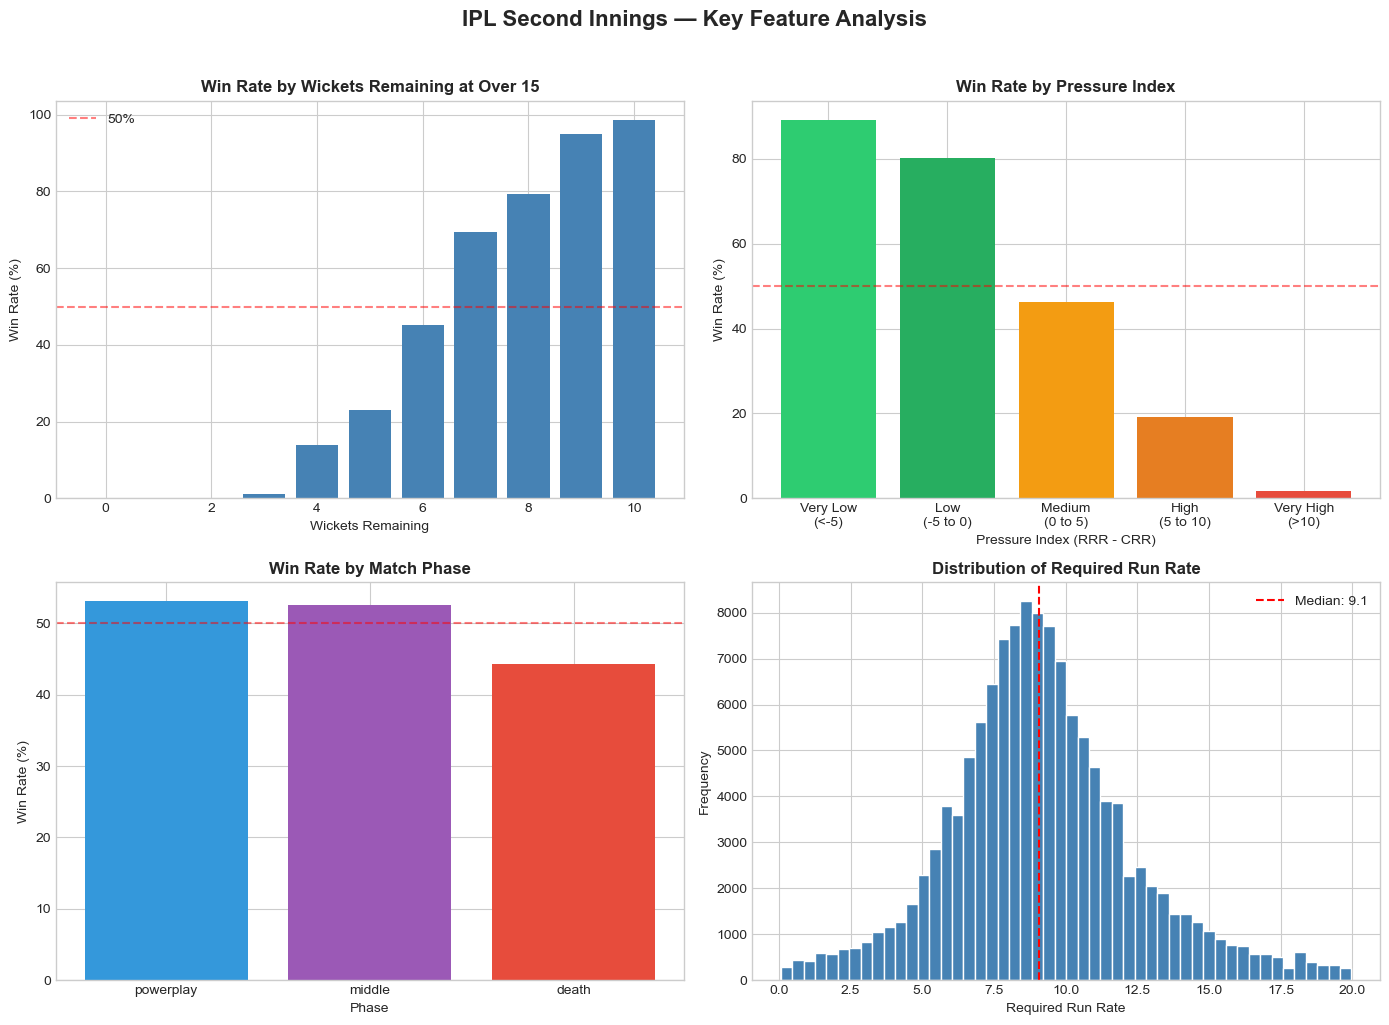

In [16]:
# EDA on second innings features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Win rate by wickets remaining at over 15
over15 = df2[df2['over'] == 14]  # over 15 (0-indexed)
wr_by_wickets = over15.groupby('wickets_remaining')['batting_team_won'].mean()
axes[0,0].bar(wr_by_wickets.index, wr_by_wickets.values * 100, color='steelblue')
axes[0,0].set_title('Win Rate by Wickets Remaining at Over 15', fontweight='bold')
axes[0,0].set_xlabel('Wickets Remaining')
axes[0,0].set_ylabel('Win Rate (%)')
axes[0,0].axhline(50, color='red', linestyle='--', alpha=0.5, label='50%')
axes[0,0].legend()

# 2. Win rate by pressure index buckets
df2['pressure_bucket'] = pd.cut(df2['pressure_index'], 
                                  bins=[-50, -5, 0, 5, 10, 50],
                                  labels=['Very Low\n(<-5)', 'Low\n(-5 to 0)', 
                                          'Medium\n(0 to 5)', 'High\n(5 to 10)', 'Very High\n(>10)'])
wr_by_pressure = df2.groupby('pressure_bucket')['batting_team_won'].mean()
colors = ['#2ecc71', '#27ae60', '#f39c12', '#e67e22', '#e74c3c']
axes[0,1].bar(wr_by_pressure.index, wr_by_pressure.values * 100, color=colors)
axes[0,1].set_title('Win Rate by Pressure Index', fontweight='bold')
axes[0,1].set_xlabel('Pressure Index (RRR - CRR)')
axes[0,1].set_ylabel('Win Rate (%)')
axes[0,1].axhline(50, color='red', linestyle='--', alpha=0.5)

# 3. Win rate by phase
wr_by_phase = df2.groupby('phase')['batting_team_won'].mean()
axes[1,0].bar(wr_by_phase.index, wr_by_phase.values * 100, 
               color=['#3498db', '#9b59b6', '#e74c3c'])
axes[1,0].set_title('Win Rate by Match Phase', fontweight='bold')
axes[1,0].set_xlabel('Phase')
axes[1,0].set_ylabel('Win Rate (%)')
axes[1,0].axhline(50, color='red', linestyle='--', alpha=0.5)

# 4. Distribution of required run rate
axes[1,1].hist(df2[df2['rrr'] < 20]['rrr'], bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Distribution of Required Run Rate', fontweight='bold')
axes[1,1].set_xlabel('Required Run Rate')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(df2['rrr'].median(), color='red', linestyle='--', 
                   label=f"Median: {df2['rrr'].median():.1f}")
axes[1,1].legend()

plt.suptitle('IPL Second Innings — Key Feature Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_second_innings.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Model Building

We train three models and compare performance. The goal is both accuracy and calibration — when the model says 70%, teams should win ~70% of the time.

In [17]:
# Prepare feature matrix
features = ['runs_required', 'balls_remaining', 'wickets_remaining',
            'crr', 'rrr', 'pressure_index']

X = df2[features].copy()
y = df2['batting_team_won']

# Remove any remaining nulls
mask = X.notnull().all(axis=1)
X = X[mask]
y = y[mask]

# Train test split — use time-based split (last 2 seasons as test)
# This is more realistic than random split for time series data
test_seasons = ['2025', '2026']
test_mask = df2.loc[mask, 'season'].isin(test_seasons)

X_train = X[~test_mask]
X_test  = X[test_mask]
y_train = y[~test_mask]
y_test  = y[test_mask]

print(f'Training size: {len(X_train):,} | Test size: {len(X_test):,}')
print(f'Test seasons: {test_seasons}')

Training size: 124,718 | Test size: 10,688
Test seasons: ['2025', '2026']


In [18]:
# Train all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=10, 
                                             random_state=42, n_jobs=-1),
}

try:
    from xgboost import XGBClassifier
    models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=6, 
                                       learning_rate=0.1, random_state=42,
                                       eval_metric='logloss')
except ImportError:
    print('XGBoost not installed, skipping')

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_test, preds),
        'F1': f1_score(y_test, preds),
        'AUC': roc_auc_score(y_test, probs)
    }
    print(f'{name}: Accuracy={results[name]["Accuracy"]:.3f} | F1={results[name]["F1"]:.3f} | AUC={results[name]["AUC"]:.3f}')

results_df = pd.DataFrame(results).T
print('\nModel Comparison:')
print(results_df.round(3))

Logistic Regression: Accuracy=0.800 | F1=0.789 | AUC=0.898
Random Forest: Accuracy=0.805 | F1=0.798 | AUC=0.898
XGBoost: Accuracy=0.804 | F1=0.795 | AUC=0.896

Model Comparison:
                     Accuracy     F1    AUC
Logistic Regression     0.800  0.789  0.898
Random Forest           0.805  0.798  0.898
XGBoost                 0.804  0.795  0.896


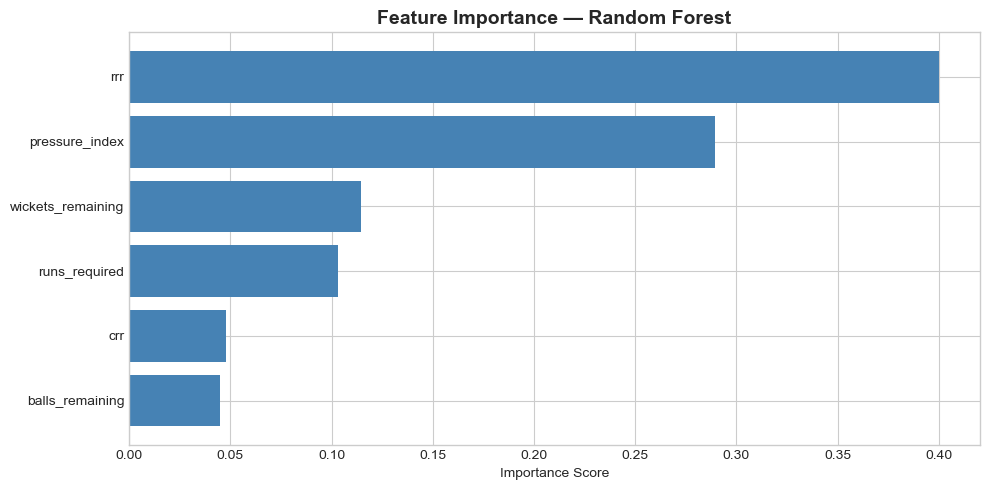

             Feature  Importance
4                rrr    0.400356
5     pressure_index    0.289492
2  wickets_remaining    0.114405
0      runs_required    0.103048
3                crr    0.047900
1    balls_remaining    0.044800


In [19]:
# Feature importance from Random Forest
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print(importance_df.sort_values('Importance', ascending=False))

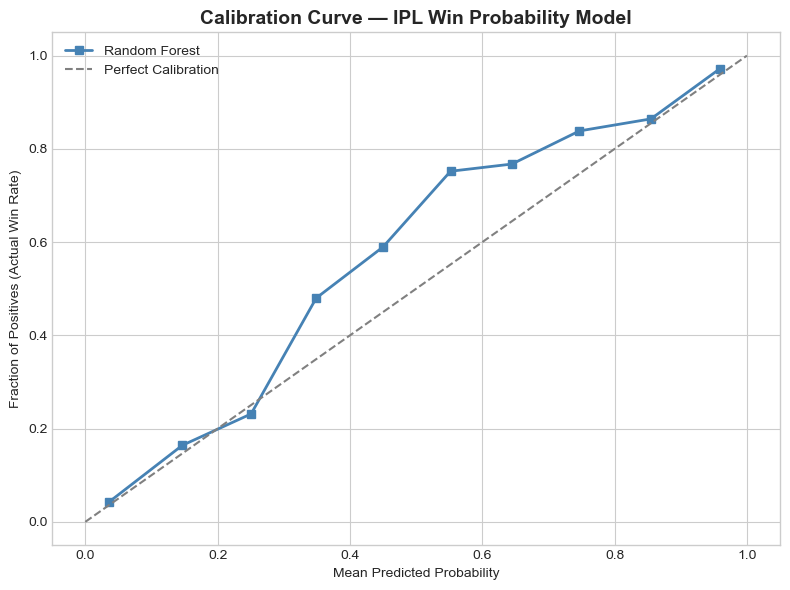


Calibration Check (Predicted vs Actual):
  Predicted: 0.04 | Actual: 0.04 | Diff: 0.01 ✓
  Predicted: 0.15 | Actual: 0.16 | Diff: 0.02 ✓
  Predicted: 0.25 | Actual: 0.23 | Diff: 0.02 ✓
  Predicted: 0.35 | Actual: 0.48 | Diff: 0.13 ⚠
  Predicted: 0.45 | Actual: 0.59 | Diff: 0.14 ⚠
  Predicted: 0.55 | Actual: 0.75 | Diff: 0.20 ⚠
  Predicted: 0.64 | Actual: 0.77 | Diff: 0.12 ⚠
  Predicted: 0.75 | Actual: 0.84 | Diff: 0.09 ⚠
  Predicted: 0.85 | Actual: 0.86 | Diff: 0.01 ✓
  Predicted: 0.96 | Actual: 0.97 | Diff: 0.01 ✓


In [20]:
# Calibration curve — critical for probability models
rf_probs = rf_model.predict_proba(X_test)[:, 1]
fraction_pos, mean_pred = calibration_curve(y_test, rf_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred, fraction_pos, 's-', label='Random Forest', color='steelblue', linewidth=2)
plt.plot([0, 1], [0, 1], '--', label='Perfect Calibration', color='gray')
plt.title('Calibration Curve — IPL Win Probability Model', fontsize=14, fontweight='bold')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Win Rate)')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()

print('\nCalibration Check (Predicted vs Actual):')
for p, a in zip(mean_pred, fraction_pos):
    diff = abs(p - a)
    flag = '✓' if diff < 0.05 else '⚠'
    print(f'  Predicted: {p:.2f} | Actual: {a:.2f} | Diff: {diff:.2f} {flag}')

## 6b. Feature Experiment — Does Team, Venue, or Player Skill Matter?

We test whether adding team identity, venue, and player-level features improves on the match-state-only model.

In [21]:
# --- Experiment A: team + venue ---
from sklearn.preprocessing import LabelEncoder

df2_test = df2.copy()
df2_test['batting_team_enc'] = LabelEncoder().fit_transform(df2_test['batting_team'])
df2_test['bowling_team_enc'] = LabelEncoder().fit_transform(df2_test['bowling_team'])
df2_test['venue_enc'] = LabelEncoder().fit_transform(df2_test['venue'].fillna('Unknown'))

features_extended = features + ['batting_team_enc', 'bowling_team_enc', 'venue_enc']

X_ext = df2_test[features_extended].copy()
y_ext = df2_test['batting_team_won']
mask_ext = X_ext.notnull().all(axis=1)
X_ext, y_ext = X_ext[mask_ext], y_ext[mask_ext]

test_mask_ext = df2_test.loc[mask_ext, 'season'].isin(test_seasons)
X_train_ext, X_test_ext = X_ext[~test_mask_ext], X_ext[test_mask_ext]
y_train_ext, y_test_ext = y_ext[~test_mask_ext], y_ext[test_mask_ext]

rf_extended = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_extended.fit(X_train_ext, y_train_ext)
ext_preds = rf_extended.predict(X_test_ext)
ext_probs = rf_extended.predict_proba(X_test_ext)[:, 1]

print('=== BASELINE (match state only) ===')
print(f"Accuracy: {results['Random Forest']['Accuracy']:.3f} | AUC: {results['Random Forest']['AUC']:.3f}")
print('\n=== + team + venue ===')
print(f'Accuracy: {accuracy_score(y_test_ext, ext_preds):.3f} | AUC: {roc_auc_score(y_test_ext, ext_probs):.3f}')
print('\nFinding: team and venue add < 1% — situational pressure dominates outcome, not identity.')

=== BASELINE (match state only) ===
Accuracy: 0.805 | AUC: 0.898

=== + team + venue ===
Accuracy: 0.804 | AUC: 0.900

Finding: team and venue add < 1% — situational pressure dominates outcome, not identity.


In [22]:
# --- Experiment B: batter skill, recent momentum, derived pressure ---
df2_v3 = df2.copy()

# batter_skill: career strike rate
batter_stats = df.groupby('batter').agg(
    total_runs=('batter_runs', 'sum'),
    total_balls=('batter_balls', 'sum')
).reset_index()
batter_stats['career_strike_rate'] = (batter_stats['total_runs'] / 
                                       batter_stats['total_balls'].replace(0, 1)) * 100
batter_sr_map = dict(zip(batter_stats['batter'], batter_stats['career_strike_rate']))
df2_v3['batter_skill'] = df2_v3['batter'].map(batter_sr_map).fillna(
    batter_stats['career_strike_rate'].median())

# recent_wickets: wickets lost in last 3 overs
df2_v3 = df2_v3.sort_values(['match_id', 'ball_no'])
df2_v3['recent_wickets'] = df2_v3.groupby('match_id')['wickets_fallen'].transform(
    lambda x: x.diff(periods=1).rolling(window=18, min_periods=1).sum()
).fillna(0)

# required_boundary_rate: derived from rrr (kept only for comparison, later dropped)
df2_v3['required_boundary_rate'] = df2_v3['rrr'] / 4

feature_sets = {
    'Baseline (6 features)': features,
    '+ batter_skill': features + ['batter_skill'],
    '+ recent_wickets': features + ['recent_wickets'],
    '+ required_boundary_rate': features + ['required_boundary_rate'],
    '+ all 3 new features': features + ['batter_skill', 'recent_wickets', 'required_boundary_rate'],
}

comparison_results = {}
for set_name, feat_list in feature_sets.items():
    X_v3 = df2_v3[feat_list].copy()
    y_v3 = df2_v3['batting_team_won']
    mask_v3 = X_v3.notnull().all(axis=1)
    X_v3, y_v3 = X_v3[mask_v3], y_v3[mask_v3]
    test_mask_v3 = df2_v3.loc[mask_v3, 'season'].isin(test_seasons)
    X_tr, X_te = X_v3[~test_mask_v3], X_v3[test_mask_v3]
    y_tr, y_te = y_v3[~test_mask_v3], y_v3[test_mask_v3]

    model_v3 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
    model_v3.fit(X_tr, y_tr)
    preds_v3 = model_v3.predict(X_te)
    probs_v3 = model_v3.predict_proba(X_te)[:, 1]
    comparison_results[set_name] = {
        'Accuracy': accuracy_score(y_te, preds_v3),
        'AUC': roc_auc_score(y_te, probs_v3),
        'N_features': len(feat_list)
    }

comparison_df = pd.DataFrame(comparison_results).T
print(comparison_df.round(4))
print('\nFinding: batter_skill is the best single addition.')
print('required_boundary_rate is redundant (derived from rrr) — drop it.')
print('all-3-combined underperforms batter_skill alone — more features != better here.')

                          Accuracy     AUC  N_features
Baseline (6 features)       0.8038  0.8980         6.0
+ batter_skill              0.8109  0.9023         7.0
+ recent_wickets            0.8074  0.9014         7.0
+ required_boundary_rate    0.8044  0.8988         7.0
+ all 3 new features        0.8091  0.9019         9.0

Finding: batter_skill is the best single addition.
required_boundary_rate is redundant (derived from rrr) — drop it.
all-3-combined underperforms batter_skill alone — more features != better here.


## 6c. Final Model — Baseline + batter_skill

Based on the experiments above, `batter_skill` is the only feature worth keeping beyond the original six. This becomes the model used for all analysis from here on — note `rf_model` is being **overwritten** here, so every cell after this point uses the improved 7-feature model.

In [23]:
final_features = ['runs_required', 'balls_remaining', 'wickets_remaining',
                   'crr', 'rrr', 'pressure_index', 'batter_skill']

X = df2_v3[final_features].copy()
y = df2_v3['batting_team_won']

mask = X.notnull().all(axis=1)
X, y = X[mask], y[mask]

test_mask = df2_v3.loc[mask, 'season'].isin(test_seasons)
X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]

print(f'Training size: {len(X_train):,} | Test size: {len(X_test):,}')

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

final_preds = rf_model.predict(X_test)
final_probs = rf_model.predict_proba(X_test)[:, 1]

print(f'Final Model -- Accuracy: {accuracy_score(y_test, final_preds):.3f} | '
      f'F1: {f1_score(y_test, final_preds):.3f} | AUC: {roc_auc_score(y_test, final_probs):.3f}')

Training size: 124,718 | Test size: 10,688
Final Model -- Accuracy: 0.811 | F1: 0.805 | AUC: 0.902


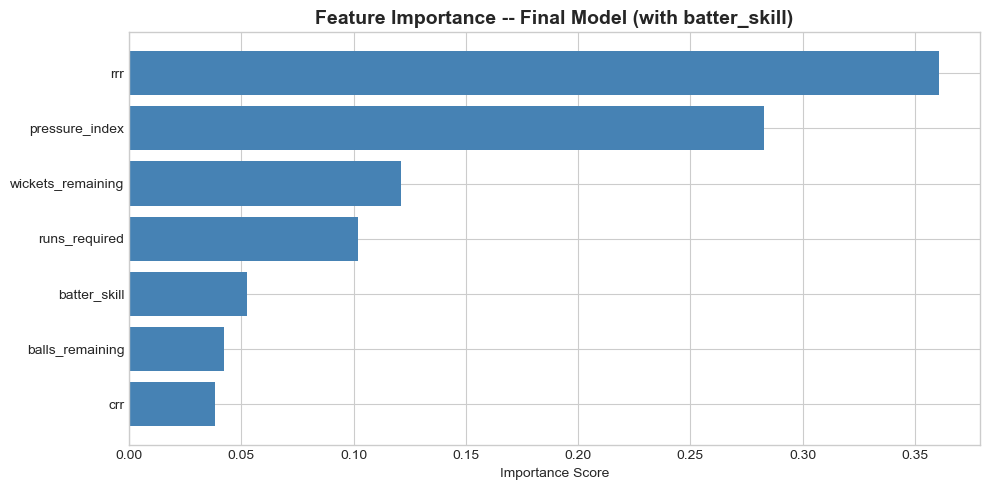

             Feature  Importance
4                rrr    0.360936
5     pressure_index    0.282871
2  wickets_remaining    0.120984
0      runs_required    0.102142
6       batter_skill    0.052345
1    balls_remaining    0.042373
3                crr    0.038349


In [24]:
# Feature importance -- final model
importance_df = pd.DataFrame({
    'Feature': final_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.title('Feature Importance -- Final Model (with batter_skill)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_final.png', dpi=150)
plt.show()
print(importance_df.sort_values('Importance', ascending=False))

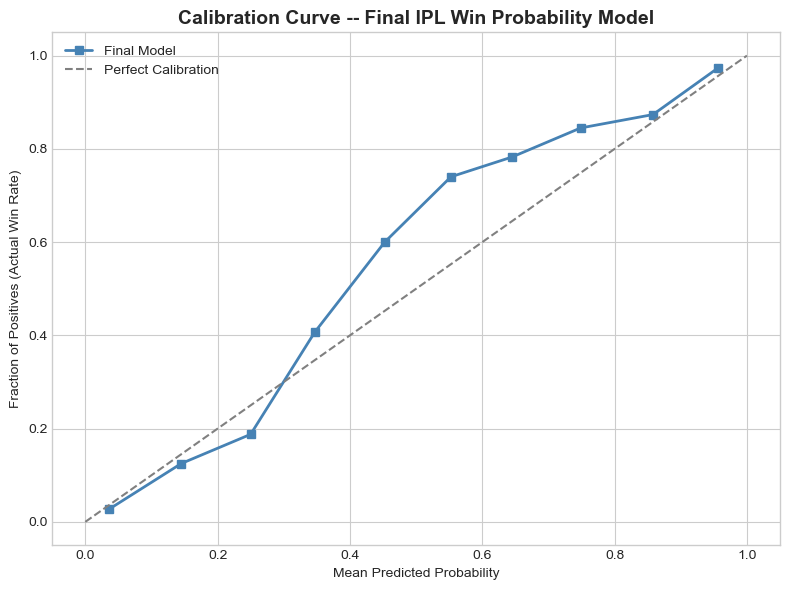


Calibration Check (Predicted vs Actual):
  Predicted: 0.04 | Actual: 0.03 | Diff: 0.01 ✓
  Predicted: 0.15 | Actual: 0.13 | Diff: 0.02 ✓
  Predicted: 0.25 | Actual: 0.19 | Diff: 0.06 ⚠
  Predicted: 0.35 | Actual: 0.41 | Diff: 0.06 ⚠
  Predicted: 0.45 | Actual: 0.60 | Diff: 0.15 ⚠
  Predicted: 0.55 | Actual: 0.74 | Diff: 0.19 ⚠
  Predicted: 0.64 | Actual: 0.78 | Diff: 0.14 ⚠
  Predicted: 0.75 | Actual: 0.84 | Diff: 0.10 ⚠
  Predicted: 0.86 | Actual: 0.87 | Diff: 0.02 ✓
  Predicted: 0.96 | Actual: 0.97 | Diff: 0.02 ✓


In [25]:
# Calibration curve -- final model
fraction_pos, mean_pred = calibration_curve(y_test, final_probs, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(mean_pred, fraction_pos, 's-', label='Final Model', color='steelblue', linewidth=2)
plt.plot([0, 1], [0, 1], '--', label='Perfect Calibration', color='gray')
plt.title('Calibration Curve -- Final IPL Win Probability Model', fontsize=14, fontweight='bold')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Win Rate)')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=150)
plt.show()

print('\nCalibration Check (Predicted vs Actual):')
for p, a in zip(mean_pred, fraction_pos):
    diff = abs(p - a)
    flag = chr(10003) if diff < 0.05 else chr(9888)
    print(f'  Predicted: {p:.2f} | Actual: {a:.2f} | Diff: {diff:.2f} {flag}')

## 7. Choking Analysis

**Definition:** A team "chokes" when they had a win probability ≥ 80% at some point in the innings but still lost the match.

We identify which teams do this most often — a genuinely novel analysis built on top of our win probability model.

In [26]:
# Add win probability predictions to the second innings dataframe
# NOTE: uses df2_v3 and final_features so this matches the final model (with batter_skill)
X_full = df2_v3[final_features].copy()
mask_full = X_full.notnull().all(axis=1)
X_full_clean = X_full[mask_full]

df2_clean = df2_v3[mask_full].copy()
df2_clean['win_prob'] = rf_model.predict_proba(X_full_clean)[:, 1]

print('Win probability added')
print(df2_clean[['match_id', 'over', 'batting_team', 'win_prob', 'batting_team_won']].head(10))

Win probability added
     match_id  over                 batting_team  win_prob  batting_team_won
124    335982     0  Royal Challengers Bangalore  0.175042                 0
125    335982     0  Royal Challengers Bangalore  0.104579                 0
126    335982     0  Royal Challengers Bangalore  0.129189                 0
127    335982     0  Royal Challengers Bangalore  0.111764                 0
128    335982     0  Royal Challengers Bangalore  0.154052                 0
129    335982     0  Royal Challengers Bangalore  0.076914                 0
130    335982     0  Royal Challengers Bangalore  0.048354                 0
131    335982     1  Royal Challengers Bangalore  0.049551                 0
132    335982     1  Royal Challengers Bangalore  0.026609                 0
133    335982     1  Royal Challengers Bangalore  0.104906                 0


In [27]:
# Choking analysis
CHOKE_THRESHOLD = 0.80  # team had 80%+ win probability at some point

# For each match, find max win probability the chasing team reached
match_max_prob = df2_clean.groupby(['match_id', 'batting_team']).agg(
    max_win_prob=('win_prob', 'max'),
    batting_team_won=('batting_team_won', 'first')
).reset_index()

# Matches where team had 80%+ win prob
high_prob_matches = match_max_prob[match_max_prob['max_win_prob'] >= CHOKE_THRESHOLD].copy()
high_prob_matches['choked'] = (high_prob_matches['batting_team_won'] == 0).astype(int)

# Choke rate by team
choke_stats = high_prob_matches.groupby('batting_team').agg(
    times_in_winning_position=('match_id', 'count'),
    times_choked=('choked', 'sum')
).reset_index()

choke_stats['choke_rate'] = (choke_stats['times_choked'] / 
                              choke_stats['times_in_winning_position'] * 100).round(1)

# Filter to teams with enough sample size
choke_stats = choke_stats[choke_stats['times_in_winning_position'] >= 10]
choke_stats = choke_stats.sort_values('choke_rate', ascending=False)

print('Team Choking Analysis (when win prob reached 80%+):')
print(choke_stats.to_string(index=False))

Team Choking Analysis (when win prob reached 80%+):
               batting_team  times_in_winning_position  times_choked  choke_rate
        Pune Warriors India                         11             5        45.5
        Sunrisers Hyderabad                         73            17        23.3
Royal Challengers Bangalore                         73            13        17.8
      Kolkata Knight Riders                         93            16        17.2
             Delhi Capitals                         88            15        17.0
       Lucknow Super Giants                         14             2        14.3
             Gujarat Titans                         23             3        13.0
           Rajasthan Royals                         79            10        12.7
             Mumbai Indians                         83            10        12.0
               Punjab Kings                         75             9        12.0
        Chennai Super Kings                         74   

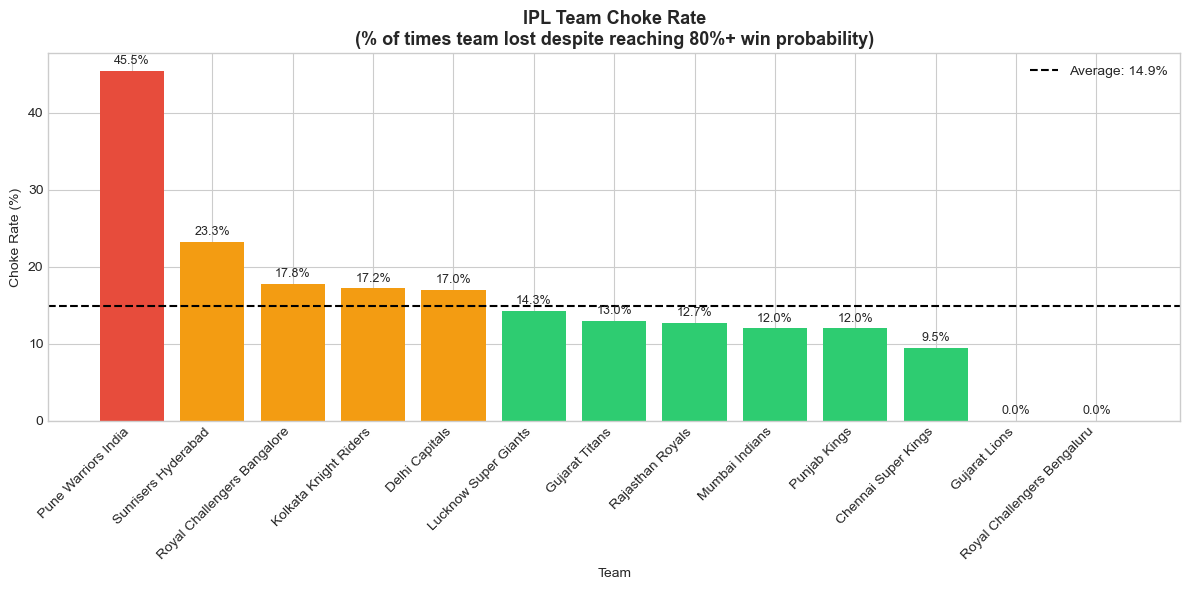

In [28]:
# Visualize choke rates
plt.figure(figsize=(12, 6))
colors = ['#e74c3c' if r > 25 else '#f39c12' if r > 15 else '#2ecc71' 
          for r in choke_stats['choke_rate']]
bars = plt.bar(choke_stats['batting_team'], choke_stats['choke_rate'], color=colors)
plt.axhline(choke_stats['choke_rate'].mean(), color='black', linestyle='--', 
            linewidth=1.5, label=f"Average: {choke_stats['choke_rate'].mean():.1f}%")
plt.title('IPL Team Choke Rate\n(% of times team lost despite reaching 80%+ win probability)',
          fontsize=13, fontweight='bold')
plt.xlabel('Team')
plt.ylabel('Choke Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()

# Add value labels
for bar, val in zip(bars, choke_stats['choke_rate']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('choke_analysis.png', dpi=150)
plt.show()

## 8. Upset Detector

Matches where a team had ≥ 80% win probability but still lost — the biggest collapses in IPL history.

In [30]:
# Find biggest upsets — matches where win prob crossed 80% but team lost
choked_matches = high_prob_matches[high_prob_matches['choked'] == 1].copy()
choked_matches = choked_matches.sort_values('max_win_prob', ascending=False)

# Add match details
match_details = df.drop_duplicates('match_id')[['match_id', 'date', 'venue', 
                                                  'season', 'batting_team', 
                                                  'bowling_team', 'win_outcome']]
# Get second innings batting team correctly
second_inn_details = df[df['innings'] == 2].drop_duplicates('match_id')[[
    'match_id', 'batting_team', 'bowling_team']].rename(
    columns={'batting_team': 'chasing_team', 'bowling_team': 'defending_team'})

match_info = match_details.merge(second_inn_details, on='match_id', how='left')
upset_details = choked_matches.merge(
    match_info[['match_id', 'date', 'venue', 'season', 'win_outcome', 'defending_team']], 
    on='match_id', how='left'
)

print(f'Total upsets found: {len(upset_details)}')
print(f'\nTop 15 Biggest Upsets (team had highest win prob but still lost):')
print(upset_details[['date', 'season', 'batting_team', 'defending_team', 
                       'max_win_prob', 'win_outcome']].head(15).to_string(index=False))

Total upsets found: 108

Top 15 Biggest Upsets (team had highest win prob but still lost):
      date  season                batting_team        defending_team  max_win_prob win_outcome
2021-09-21    2021                Punjab Kings      Rajasthan Royals      0.978294      2 runs
2025-04-15    2025       Kolkata Knight Riders          Punjab Kings      0.973686     16 runs
2013-04-16    2013 Royal Challengers Bangalore        Delhi Capitals      0.973236         NaN
2008-05-08 2007-08 Royal Challengers Bangalore Kolkata Knight Riders      0.969349      5 runs
2009-05-07    2009                Punjab Kings   Chennai Super Kings      0.968135     12 runs
2019-03-30    2019              Delhi Capitals Kolkata Knight Riders      0.967811         NaN
2010-03-21 2009-10         Chennai Super Kings          Punjab Kings      0.964088         NaN
2018-05-02    2018            Rajasthan Royals        Delhi Capitals      0.956215      4 runs
2023-04-22    2023        Lucknow Super Giants        

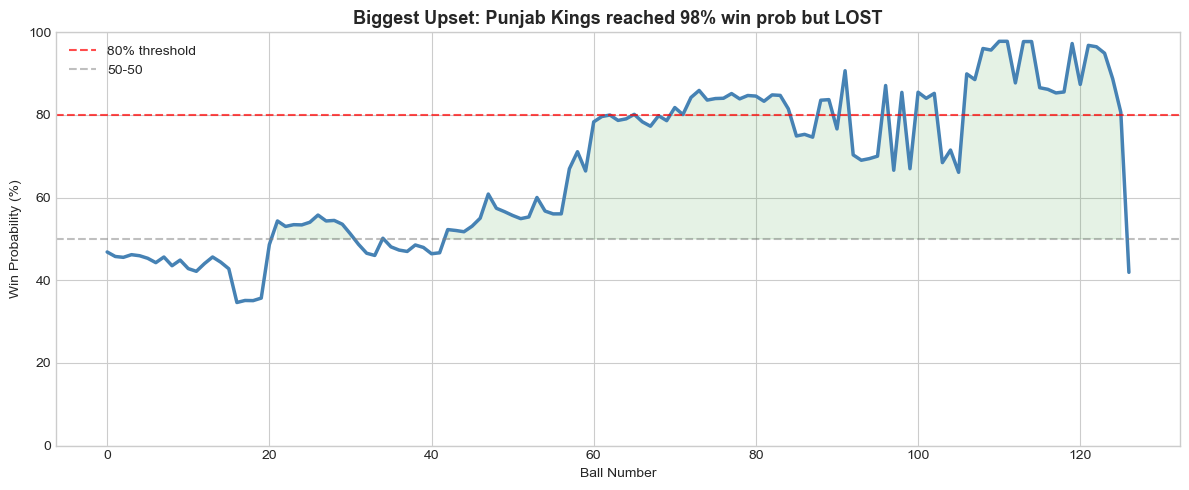

In [31]:
# Plot win probability curve for the biggest upset
biggest_upset_id = upset_details.iloc[0]['match_id']
biggest_upset_team = upset_details.iloc[0]['batting_team']
biggest_upset_prob = upset_details.iloc[0]['max_win_prob']

upset_curve = df2_clean[df2_clean['match_id'] == biggest_upset_id].sort_values('ball_no')

plt.figure(figsize=(12, 5))
plt.plot(range(len(upset_curve)), upset_curve['win_prob'] * 100, 
         linewidth=2.5, color='steelblue')
plt.axhline(80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
plt.axhline(50, color='gray', linestyle='--', alpha=0.5, label='50-50')
plt.fill_between(range(len(upset_curve)), upset_curve['win_prob'] * 100, 
                  50, where=upset_curve['win_prob'] > 0.5,
                  alpha=0.1, color='green')
plt.title(f'Biggest Upset: {biggest_upset_team} reached {biggest_upset_prob:.0%} win prob but LOST',
          fontsize=13, fontweight='bold')
plt.xlabel('Ball Number')
plt.ylabel('Win Probability (%)')
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig('biggest_upset.png', dpi=150)
plt.show()

### 8b. Upset Detector — Toss-Loser Wins (a different cut)

While Choking Analysis looks at team-level aggregate collapse rate, this looks at individual matches where a team **lost the toss** and was also a statistical underdog at some point — a compounding-disadvantage view rather than a restatement of choking.

In [32]:
# Upset Detector v2: Toss-loser wins despite the odds
toss_df['toss_loser'] = np.where(
    toss_df['toss_winner'] == toss_df['batting_team'],
    toss_df['bowling_team'],
    toss_df['batting_team']
)
toss_df['toss_loser_won'] = (toss_df['toss_loser'] == toss_df['match_winner']).astype(int)

toss_loser_win_rate = toss_df['toss_loser_won'].mean()
print(f'Toss LOSER win rate: {toss_loser_win_rate:.1%}')
print('(If toss truly mattered, this would be well below 50%)')

# Combine with model: matches where the eventual winner lost the toss AND overcame a high-probability deficit
upset_v2 = choked_matches.merge(
    toss_df[['match_id', 'toss_winner', 'toss_loser_won']], 
    on='match_id', how='left'
)
double_upsets = upset_v2[upset_v2['toss_loser_won'] == 1]
print(f'\nMatches where team lost toss AND opponent had 80%+ win prob but still lost: {len(double_upsets)}')

Toss LOSER win rate: 53.7%
(If toss truly mattered, this would be well below 50%)

Matches where team lost toss AND opponent had 80%+ win prob but still lost: 38


## 9. Save Model & Key Findings

In [33]:
# Save the model
with open('ipl_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('features.pkl', 'wb') as f:
    pickle.dump(features, f)

print('Model saved successfully')

# Save choke stats for app
choke_stats.to_csv('choke_stats.csv', index=False)
print('Choke stats saved')

Model saved successfully
Choke stats saved


In [39]:
def predict_win_prob(runs_required, balls_remaining, wickets_remaining,
                     runs_scored, balls_bowled, batter_skill=130):
    """
    Predict win probability for the chasing team.
    batter_skill: career strike rate of current batter (default ~130, the dataset median)
    Returns probability between 0 and 1.
    """
    overs_completed = balls_bowled / 6
    crr = runs_scored / max(overs_completed, 0.1)
    rrr = (runs_required * 6) / max(balls_remaining, 1)
    pressure_index = rrr - crr
    
    X_input = pd.DataFrame([{
        'runs_required': runs_required,
        'balls_remaining': balls_remaining,
        'wickets_remaining': wickets_remaining,
        'crr': crr,
        'rrr': rrr,
        'pressure_index': pressure_index,
        'batter_skill': batter_skill
    }])
    
    prob = rf_model.predict_proba(X_input)[0][1]
    return prob

# Example: CSK needs 65 off 48 balls with 6 wickets remaining, batter has SR of 145
prob = predict_win_prob(
    runs_required=65,
    balls_remaining=48,
    wickets_remaining=6,
    runs_scored=95,
    balls_bowled=72,
    batter_skill=145
)
print(f'Chasing team win probability: {prob:.1%}')
print(f'Defending team win probability: {1-prob:.1%}')

Chasing team win probability: 61.3%
Defending team win probability: 38.7%


In [40]:
import pickle

# Save the final model
with open('ipl_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save batter skill lookup (so app can compute it without raw data)
batter_stats[['batter', 'career_strike_rate']].to_csv('batter_skill_lookup.csv', index=False)

# Save team list and venue list for dropdowns
teams_list = sorted(df2_v3['batting_team'].unique().tolist())
venues_list = sorted(df['venue'].dropna().unique().tolist())

import json
with open('teams_venues.json', 'w') as f:
    json.dump({'teams': teams_list, 'venues': venues_list}, f)

# Save choke stats for the app's analysis tab
choke_stats.to_csv('choke_stats.csv', index=False)

print('All files saved:')
print('- ipl_model.pkl')
print('- batter_skill_lookup.csv')
print('- teams_venues.json')
print('- choke_stats.csv')

All files saved:
- ipl_model.pkl
- batter_skill_lookup.csv
- teams_venues.json
- choke_stats.csv
